# Модуль А. Анализ и предобработка данных

## Импортирование библиотек

In [3]:
# для работы с датафреймами
import pandas as pd

# для визуализации результатов
import matplotlib.pyplot as plt

# для работы с массивами
import numpy as np

# для работы с файловой системой
import os, shutil

# модуль со словарями
from collections import defaultdict

# для создания прогресс-бара
from tqdm import tqdm

# nlp библиотека
import nltk
# модуль со стоп словами
from nltk.corpus import stopwords

# для создания облаков слов
from wordcloud import WordCloud

# модуль с регулярными приложениями
import re

# для работы со строками
import string

# 
from datasets import Dataset, DatasetDict

# вспомогательные функции 
from function import *

#
from transformers import T5Tokenizer

#
import evaluate

# 
import torch


c:\Users\user1\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Применяем стиль dark_background
plt.style.use('dark_background')

In [5]:
# Скачиваем стоп-слова для русского языка
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# добавление стоп-слов
stop_words.update({"в","и","а","к","с","по","на","для","это","с"})

### Функции

Все функции реализованы в файле `function.py`

```py
# процедура для генерации облака слов
def generate_wordcoud(text: str, color: str = 'black'):
    '''Процедура для создания облака слов'''
    # создаем объект - облако слов
    wordcloud = WordCloud(
        width=800,              # ширина
        height=400,             # высота
        background_color=color  # цвет фона
    ).generate(text)
    
    # визуализация облака слова
    plt.figure(figsize=(10,5))                          # размер фигуры
    plt.imshow(wordcloud, interpolation='bilinear')     # загружаем объект для вывода
    plt.axis('off')                                     # отключаем сетку
    plt.show()                                          # вывод изображения
    
```

```py
# функция для чистки стоп слов
def clean_text(text: str, stop_words: set):
    '''
    Функция для чистки текста от стоп слов
        Args:
            - test (str): текст, который нужно почистить от стоп слов
            - stop_words (set): множество стоп слов
        Returns:
            - отфильтрованный текст (str)
    '''
    # создаем список слов используя split()
    words = text.split()
    # фильтруем слова используя заданное множество
    filtered_words = [word for word in words if word.lower() not in stop_words]
    # возвращаем почищенный текст
    return ' '.join(filtered_words)
```

```py
# функция для построения графиков
def see_distribution(data_stats: dict, 
                     title: str = 'Values distribution',
                     xlabel: str = 'Keys',
                     ylabel: str = 'Values',
                     color: str = 'lightblue',
                     graph_type: str = 'bar',
                     grid: bool = True,
                     meta: bool = True
                     ):
    '''
    Процедура для построения графика распределения данных
        Args:
        - data_stats (dict): словарь с собранной статистикой
        - title (str): название графика
        - xlabel (str): название икса
        - ylabel (str): название игрика
        - color (str): цвет графика
        - grid (bool): включение сетки
        - meta (bool): включение метаинформации
    '''
    # парсим входной словарь
    x, y = data_stats.keys(), data_stats.values()
    
    plt.figure(figsize=(10,5))      # размер фигуры
    # в зависимости от типа графика, строим нужный
    match graph_type:
        # если тип графика - bar
        case 'bar':
            plt.bar(x, y, color=color)      # тип графика
        # если тип графика - plot   
        case 'plot':
            plt.plot(x, y, color=color)     # тип графика
        # если тип графика - plot   
        case 'scatter':
            plt.scatter(x, y, color=color)     # тип графика


    # настраиваем график
    plt.title(title)                # название графика
    plt.xlabel(xlabel)              # подпись к иксу
    plt.ylabel(ylabel)              # подпись к игрику

    # если включена сетка
    if grid:
        # включаем сетку
        plt.grid(True)

    plt.show()                      # вывод графика

    # если включен вывод метаинформации
    if meta:
        # всего значений
        print(f'Counts: {len(x)}')
        # вывод минимального значения
        print(f'Min: {min(y)}')
        # вывод среднего значения
        print(f'Mean: {sum(y)/len(y):.2f}')
        # вывод максмиального значения
        print(f'Max: {max(y)}')
```

In [7]:
# функция для показа примеров
def show_samples(dataset, num_samples: int = 3, seed: int = 42):
    # собираем указанное кол-во примеров
    samples = dataset['train'].shuffle(seed=seed).select(range(num_samples))
    # проходимся по каждому примеру
    for sample in samples:
        # вывод примеров
        print(f">> Статья: {sample['text'][:200]}...")
        print(f">> Аннотация: {sample['summary']}")


## Анализ и предобработка даных

Создам датафрейм, куда помещу пути ко всем файлам

In [8]:
# путь к основной папке с данными
data_dir = '../Data/DATASET/'
# логирование
print(os.path.exists(data_dir))
print(len(os.listdir(data_dir)))

True
1002


In [9]:
# Использование
dataset = Dataset.from_list(reorganize_dataset("../Data/DATASET/"))
dataset

Dataset({
    features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id'],
    num_rows: 1002
})

In [10]:
df = pd.DataFrame(dataset)
df.head()

,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id
0,../Data/DATASET/1\text.txt,../Data/DATASET/1\annotation.txt,../Data/DATASET/1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1
1,../Data/DATASET/10\text.txt,../Data/DATASET/10\annotation.txt,../Data/DATASET/10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10
2,../Data/DATASET/100\text.txt,../Data/DATASET/100\annotation.txt,../Data/DATASET/100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100
3,../Data/DATASET/1000\text.txt,../Data/DATASET/1000\annotation.txt,../Data/DATASET/1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000
4,../Data/DATASET/1001\text.txt,../Data/DATASET/1001\annotation.txt,../Data/DATASET/1001\tags.txt,"Всему миру известен данный модный дом, каждая ...","Как появилось имя Коко Шанель? Кто она, создат...","КОКО ШАНЕЛЬ, МОДА XX ВЕКА, ДУХИ CHANEL № 5, МА...",12202,226,68,11905,220,65,1846,35,12,1001


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

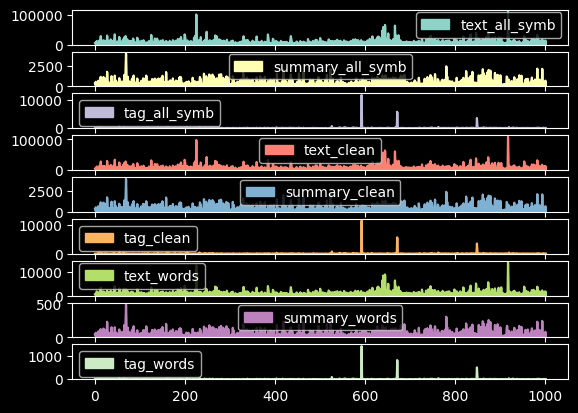

In [11]:
df.plot(kind='area', subplots=True)

На данный момент датасет выглядит довольно разрозненно, поэтому его надо отфильтровать для лучшего качества данных

### Фильтрация

In [12]:
annot_df = df[['summary_all_symb', 'summary_clean']]
annot_df.describe()

,summary_all_symb,summary_clean
count,1002.000000,1002.000000
mean,494.934132,485.199601
std,390.030148,382.093134
min,0.000000,0.000000
25%,243.000000,240.000000
50%,380.500000,374.000000
75%,606.000000,593.000000
max,4082.000000,4007.000000


In [13]:
# функция для фильтрации
def df_filter(df: pd.DataFrame, column: str, upper: float = 0.95, lower: float = 0.05):
    '''Функция для фильтрации датасета по квартилям'''
    #
    upper_bound = df[column].quantile(upper)
    #
    lower_bound = df[column].quantile(lower)

    #
    filtered_df = df[
        (df[column] >= lower_bound) & (df[column] <=upper_bound)
    ]
    
    #
    return filtered_df.dropna()

In [14]:
print(f'Размерность до фильтрации: {df.shape}')

#
filtered_df = df.copy(deep=False)
#
for column in df.columns:
    #
    if 'int64' == df[column].dtype:
        filtered_df = df_filter(filtered_df, column)
    else:
        print(column)


print(f'Размерность после фильтрации: {filtered_df.shape}')
filtered_df.head()

Размерность до фильтрации: (1002, 16)
text_path
annotation_path
tags_path
text
summary
tag
id
Размерность после фильтрации: (412, 16)


,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id
0,../Data/DATASET/1\text.txt,../Data/DATASET/1\annotation.txt,../Data/DATASET/1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1
1,../Data/DATASET/10\text.txt,../Data/DATASET/10\annotation.txt,../Data/DATASET/10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10
2,../Data/DATASET/100\text.txt,../Data/DATASET/100\annotation.txt,../Data/DATASET/100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100
3,../Data/DATASET/1000\text.txt,../Data/DATASET/1000\annotation.txt,../Data/DATASET/1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000
5,../Data/DATASET/1002\text.txt,../Data/DATASET/1002\annotation.txt,../Data/DATASET/1002\tags.txt,При разработке веб-сайта перед любым разработч...,В данной статье представлен метод разработки в...,"ПРОГРАММИРОВАНИЕ, ВЕБ-ПРОГРАММИРОВАНИЕ, БАЗА Д...",6776,301,107,6580,295,99,867,38,11,1002


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

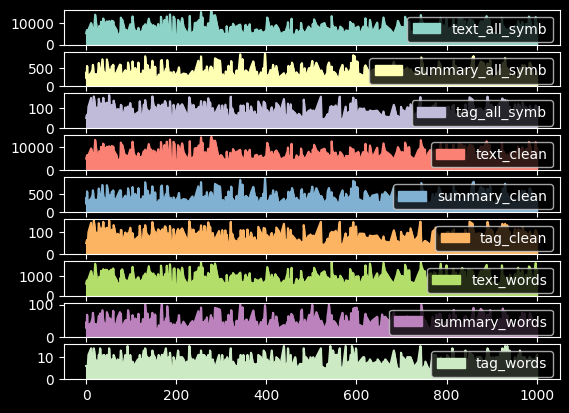

In [15]:
filtered_df.plot(kind='area', subplots=True)

In [16]:
filtered_df.describe()

,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words
count,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000
mean,7569.475728,403.148058,86.716019,7347.720874,395.873786,81.609223,938.662621,47.439320,8.449029
std,2457.748414,158.165133,30.093276,2406.313019,155.269889,28.696842,295.718820,18.649507,2.788545
min,3452.000000,165.000000,32.000000,3352.000000,162.000000,31.000000,490.000000,21.000000,4.000000
25%,5611.750000,281.000000,63.750000,5398.750000,276.500000,59.750000,703.250000,32.000000,6.000000
50%,7237.000000,372.000000,83.000000,6924.500000,366.000000,78.500000,876.000000,44.000000,8.000000
75%,8985.250000,495.000000,108.000000,8774.500000,485.000000,102.000000,1122.500000,58.000000,10.000000
max,15207.000000,924.000000,166.000000,14695.000000,911.000000,153.000000,1726.000000,101.000000,15.000000


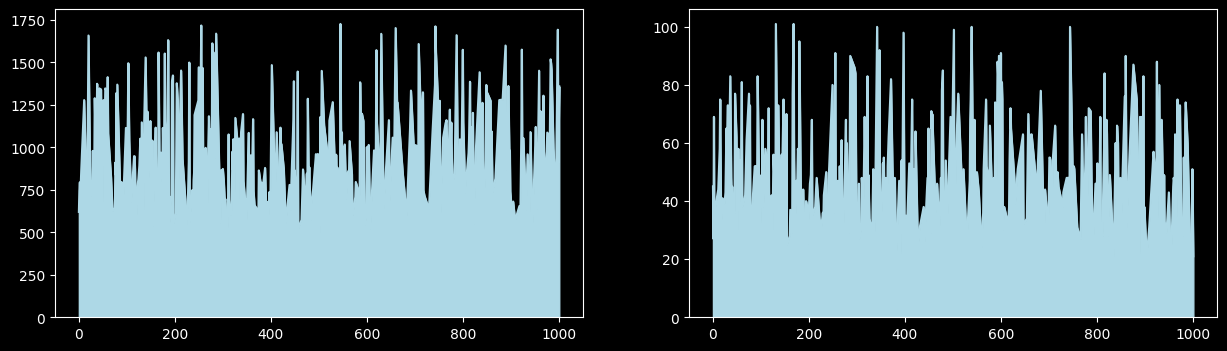

In [17]:
#
fig, ax = plt.subplots(1,2, figsize=(15,4))
#
filtered_df['text_words'].plot(kind='area', color='lightblue', ax=ax[0])
#
filtered_df['summary_words'].plot(kind='area', color='lightblue', ax=ax[1])
plt.show()

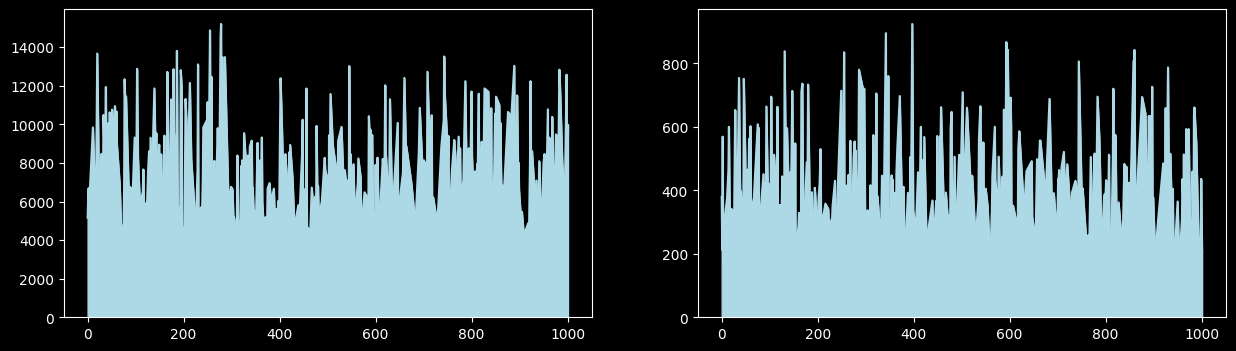

In [18]:
#
fig, ax = plt.subplots(1,2, figsize=(15,4))
#
filtered_df['text_all_symb'].plot(kind='area', color='lightblue', ax=ax[0])
#
filtered_df['summary_all_symb'].plot(kind='area', color='lightblue', ax=ax[1])
plt.show()

In [19]:
filtered_df['summary_all_symb'].describe()

count    412.000000
mean     403.148058
std      158.165133
min      165.000000
25%      281.000000
50%      372.000000
75%      495.000000
max      924.000000
Name: summary_all_symb, dtype: float64

In [20]:
samples = filtered_df.to_dict('records')

In [21]:
dataset_fin = split_dataset(samples)
dataset_fin

DatasetDict({
    train: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id'],
        num_rows: 329
    })
    validation: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id'],
        num_rows: 41
    })
    test: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id'],
        num_rows: 42
    })
})

## Работа с моделью

RuT5 — это адаптация модели T5 для русского языка. Она отлично подходит для задач генерации текста, включая суммаризацию

In [22]:
%pip install transformers datasets sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [23]:
dataset = dataset_fin

Загрузка модели и токенизатора

In [24]:
from transformers import T5Tokenizer, T5ForConditionalGeneration


model_name = "sarahai/ruT5-base-summarizer"  
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Структура выбранной модели:

In [26]:
model.to(device)

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

протестируем токенизатор `T5` на небольшом примере:

In [27]:
inputs = tokenizer("I loved reading the Hunger Games!")
inputs

{'input_ids': [865, 11851, 19789, 8, 18898, 528, 187, 1285, 17087, 705, 14127, 15944, 40, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Давайте декодируем эти входные идентификаторы с помощью функции токенизатора `convert_ids_to_tokens()`, чтобы понять, с каким токенизатором мы имеем дело:

In [28]:
tokenizer.convert_ids_to_tokens(inputs.input_ids)

['▁I',
 '▁lo',
 'ved',
 '▁',
 'read',
 'ing',
 '▁the',
 '▁H',
 'ung',
 'er',
 '▁Ga',
 'mes',
 '!',
 '</s>']

In [29]:
def preprocess_function(examples):
    inputs = [text for text in examples['text']]
    targets = [summary for summary in examples['summary']]
    
    # Токенизация с паддингом
    model_inputs = tokenizer(
        inputs, 
        max_length=512,  # Максимальная длина текста
        truncation=True,  # Обрезать тексты длиннее max_length
        padding="max_length",  # Дополнять тексты до max_length
        return_tensors="pt",  # Возвращать тензоры PyTorch
    )
    
    # Токенизация целевых текстов (summary)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets, 
            max_length=128,  # Максимальная длина суммаризации
            truncation=True,  # Обрезать суммаризации длиннее max_length
            padding="max_length",  # Дополнять суммаризации до max_length
            return_tensors="pt",  # Возвращать тензоры PyTorch
        )
    
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [30]:
tokenized_datasets = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/329 [00:00<?, ? examples/s]c:\Users\user1\NLP\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:3970: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 42/42 [00:00<00:00, 166.36 examples/s]


## Метрики для суммаризации текста

Для суммаризации одной из наиболее часто используемых метрик является оценка `ROUGE` (сокращение от `Recall-Oriented Understudy for Gisting Evaluation`). Основная идея этой метрики заключается в сравнении сгенерированного резюме с набором эталонных резюме, которые обычно создаются людьми. Чтобы сделать ее более точной, предположим, что мы хотим сравнить следующие две строчки:

In [31]:
generated_summary = "I absolutely loved reading the Hunger Games"
reference_summary = "I loved reading the Hunger Games"

Одним из способов их сравнения может быть подсчет количества перекрывающихся слов, которых в данном случае будет 6. Однако это несколько грубовато, поэтому вместо этого ROUGE основывается на вычислении оценок precision и recall для перекрытия.

Для ROUGE recall измеряет, насколько эталонное резюме соответствует сгенерированному. Если мы просто сравниваем слова, recall можно рассчитать по следующей формуле:

$$\text{Recall} = \frac{\text{Number of overlapping words}}{\text{Total number of words in reference summary}}$$

Для нашего простого примера выше эта формула дает идеальный recall 6/6 = 1; то есть все слова в эталонном резюме были получены моделью. Это может показаться замечательным, но представьте, если бы сгенерированное нами резюме было “I really really loved reading the Hunger Games all night”. Это тоже дало бы идеальный recall, но, возможно, было бы хуже, поскольку было бы многословным. Чтобы справиться с этими сценариями, мы также вычисляем precision, которая в контексте ROUGE измеряет, насколько сгенерированное резюме было релевантным:

$$\text{Precision} = \frac{\text{Number of overlapping words}}{\text{Total number of words in generated summary}}$$

Если применить это к нашему подробному резюме, то `precision` составит 6/10 = 0,6, что значительно хуже, чем `precision` 6/7 = 0,86, полученная при использовании более короткого резюме. На практике обычно вычисляют и `precision`, и `recall`, а затем `F1-score` (среднее гармоническое из `precision` и `recall`). Мы можем легко это сделать с помощью 🤗 `Datasets`, предварительно установив пакет `rouge_score`:

In [32]:
%pip install rouge_score

Note: you may need to restart the kernel to use updated packages.


а затем загрузить метрику ROUGE следующим образом:

In [33]:
rouge_score = evaluate.load('rouge')

Затем мы можем использовать функцию rouge_score.compute(), чтобы рассчитать все метрики сразу:

In [34]:
scores = rouge_score.compute(
    predictions=[generated_summary], references=[reference_summary]
)
scores

{'rouge1': np.float64(0.923076923076923),
 'rouge2': np.float64(0.7272727272727272),
 'rougeL': np.float64(0.923076923076923),
 'rougeLsum': np.float64(0.923076923076923)}

 🤗 `Dataset` вычисляет различные оценки `ROUGE`, которые основаны на различных типах детализации текста при сравнении сгенерированных и эталонных резюме. Вариант `rouge1` представляет собой перекрытие `униграмм` - это просто модный способ сказать о перекрытии слов, и это именно та метрика, которую мы обсуждали выше

`rouge2` измеряет перекрытие `биграмм` (считайте, что это перекрытие пар слов), а `rougeL` и `rougeLsum` измеряют самые длинные совпадающие последовательности слов, ища самые длинные общие подстроки в сгенерированных и эталонных резюме. Слово `“sum”` в `rougeLsum` означает, что эта метрика вычисляется для всего резюме, в то время как `rougeL` вычисляется как среднее по отдельным предложениям

Мы будем использовать эту оценку ROUGE для отслеживания эффективности нашей модели, но перед этим давайте сделаем то, что должен сделать каждый хороший NLP-практик: создадим сильную, но простую базовую модель!

Для `суммаризации` текста обычно берут первые три предложения статьи, что часто называют базвым уровнем `lead-3`. Мы могли бы использовать символы полной остановки для отслеживания границ предложений, но это не поможет при использовании таких аббревиатур, как ” U.S.” или “U.N.”. — поэтому вместо этого мы воспользуемся библиотекой `nltk`, которая включает в себя лучший алгоритм для таких случаев. Вы можете установить пакет с помощью `pip` следующим образом:

In [35]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


а затем скачайте правила пунктуации:

In [36]:
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Далее мы импортируем `токенизатор` предложений из `nltk` и создадим простую функцию для извлечения первых трех предложений в обзоре. При `суммаризации` текста принято отделять каждое предложение новой строкой, поэтому давайте включим эту функцию и протестируем ее на обучающем примере:

In [37]:
from nltk.tokenize import sent_tokenize


def three_sentence_summary(text):
    return "\n".join(sent_tokenize(text)[:3])


print(three_sentence_summary(dataset["train"][1]["text"]))

Компьютерные технологии стали частью системы обучения относительно 
недавно.
Несмотря на широкое распространение самих компьютеров, полный 
спектр их возможностей пока не используется повсеместно.
Сфера образования 
не является исключением.


Похоже, что это работает, так что теперь давайте реализуем функцию, которая извлекает эти “резюме” из датасета и вычисляет оценку ROUGE для базового уровня:

In [38]:
def evaluate_baseline(dataset, metric):
    summaries = [three_sentence_summary(text) for text in dataset["text"]]
    return metric.compute(predictions=summaries, references=dataset["summary"])

Затем мы можем использовать эту функцию для вычисления оценок `ROUGE` на валидационном множестве и немного приукрасить их с помощью `Pandas`:

In [39]:
score = evaluate_baseline(dataset["validation"], rouge_score)
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]
rouge_dict = dict((rn, round(score[rn] * 100, 2)) for rn in rouge_names)
rouge_dict

{'rouge1': np.float64(9.42),
 'rouge2': np.float64(1.3),
 'rougeL': np.float64(9.16),
 'rougeLsum': np.float64(8.38)}

Мы видим, что оценка `rouge2` значительно ниже, чем у остальных; скорее всего, это отражает тот факт, что заголовки рецензий обычно лаконичны, и поэтому базовый уровень `lead-3` слишком многословен. Теперь, когда у нас есть хороший базовый уровень для работы, давайте дообучим `ruT5`!

## Дообучение ruT5 с API Trainer

In [40]:
from transformers import Seq2SeqTrainingArguments

In [41]:
batch_size = 8
num_train_epochs = 8
# Выводим потери при обучении по каждой эпохе
logging_steps = len(tokenized_datasets["train"]) // batch_size
model_name1 = model_name.split("/")[-1]
print(model_name1)

args = Seq2SeqTrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=6,
    weight_decay=0.01,
    save_total_limit=2,
    predict_with_generate=True,
    logging_steps=logging_steps,
    fp16=True,  # Используем mixed precision для ускорения обучения
    seed=42,
    gradient_accumulation_steps=2,
)

ruT5-base-summarizer



Следующее, что нам нужно сделать, это предоставить тренеру функцию `compute_metrics()`, чтобы мы могли оценить нашу модель во время обучения. Для суммаризации это немного сложнее, чем просто вызвать `rouge_score.compute()` для прогнозов модели, поскольку нам нужно декодировать выводы и метки в текст, прежде чем мы сможем вычислить оценку `ROUGE`. Следующая функция делает именно это, а также использует функцию `sent_tokenize()` из `nltk` для разделения предложений резюме символом новой строки

In [42]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Декодируем сгенерированные резюме в текст
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    # Заменяем -100 в метках, поскольку мы не можем их декодировать
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    # Декодируем эталонные резюме в текст
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    # ROUGE ожидает символ новой строки после каждого предложения
    decoded_preds = ["\n".join(sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(sent_tokenize(label.strip())) for label in decoded_labels]
    # Вычисляем оценки ROUGE
    result = rouge_score.compute(
        predictions=decoded_preds, references=decoded_labels, use_stemmer=True
    )
    # Извлекаем медианные оценки
    result = {key: value * 100 for key, value in result.items()}
    return {k: round(v, 4) for k, v in result.items()}

In [43]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [44]:
tokenized_datasets = tokenized_datasets.remove_columns(
    dataset["train"].column_names
)

In [45]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 329
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 41
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 42
    })
})

In [120]:
features = [tokenized_datasets["train"][i] for i in range(2)]
data_collator(features)

{'input_ids': tensor([[   32,  2465,    96,  ...,    89, 11138,     2],
        [  104,  1929,    73,  ...,  5896,  1979,     2]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([[16279,   946,  2802,     7, 12296,   203, 23852,   173, 14409,  3974,
            15,    44, 17331, 23708,    74, 22919,   355,   841,  6852,     7,
             6,   728,  3587,    28, 15298,  1479,    75,    17, 23530,     9,
          9615,   164,     4,  1159,     6,  1025, 17949,    57,  1125,  2410,
            26,  7112,  5256,  1807,     4, 25662,   108,     6,  1025,   318,
          1421,  1966,  4034, 19858,     3,   622,    46,     8,  3124,     3,
          3817,  2209,     9,   222,  2325,     4,  1679,   460,     3,  3623,
          5055,     3, 27536,    29,   520, 13583,     3,   126,   143, 18267,
            11,  6694,    77,     6,     8,  3775,     3,  2492,  2209,     4,
         15745,  3148, 10262,  5124,  3619,  8601,   999,  

In [121]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [122]:
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,No log,1.483845,13.625100,2.032500,13.008100,13.055300
2,1.887800,1.462869,15.073300,2.032500,14.427300,14.753900
3,1.887800,1.444078,13.694100,2.195100,13.102500,13.200500
4,1.725000,1.438194,13.217900,0.975600,12.817200,12.963100
5,1.725000,1.432238,13.217900,0.975600,12.817200,12.963100
6,1.725800,1.429828,13.217900,0.975600,12.817200,12.963100


TrainOutput(global_step=126, training_loss=1.7782689843858992, metrics={'train_runtime': 2738.9487, 'train_samples_per_second': 0.721, 'train_steps_per_second': 0.046, 'total_flos': 1202082875965440.0, 'train_loss': 1.7782689843858992, 'epoch': 6.0})

сохранение модели

In [123]:
# Сохранение модели
model.save_pretrained("./saved_model")

# Сохранение токенизатора
tokenizer.save_pretrained("./saved_model")

('./saved_model\\tokenizer_config.json',
 './saved_model\\special_tokens_map.json',
 './saved_model\\spiece.model',
 './saved_model\\added_tokens.json')

загрузка сохраненной модели

In [31]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

# Загрузка модели
model = T5ForConditionalGeneration.from_pretrained("./saved_model")

# Загрузка токенизатора
tokenizer = T5Tokenizer.from_pretrained("./saved_model")

In [69]:
device = torch.device('cpu')
print(device)
model.to(device)

cpu


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

проверка обученной модели

In [70]:
rouge_score = evaluate.load('rouge')

In [46]:
index = 3
orig_text = dataset_fin['validation']['text'][index]
summary = dataset_fin['validation']['summary'][index]


In [47]:
input_ids = tokenizer(orig_text, return_tensors='pt').input_ids.to(device)
outputs = model.generate(input_ids, max_length=100, num_beams=4)
gen_summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

In [48]:
scores = rouge_score.compute(
    predictions=[gen_summary], references=[summary]
)
pd.DataFrame.from_dict([scores])

,rouge1,rouge2,rougeL,rougeLsum
0,0.0,0.0,0.0,0.0


In [49]:
print(f'>> Original Text: {orig_text}')
print(f'\n\n\n>> Summary: {summary}')
print(f'\n\n\n>> Generated summary: {gen_summary}')

>> Original Text: Постановка проблемы. На сегодняшний день при разработке любого
веб-приложения возникает вопрос о хранении определенных данных. С помощью программной платформы Node.js можно решить эту проблему, используя различные базы данных [1]. Они позволяют сохранять данные даже
после перезагрузки сервера, а также удалять, обновлять и добавлять их.
Именно поэтому использование баз данных является актуальным решением при разработке веб-приложений.
Анализ последних исследований и публикаций. Так как сейчас разработать веб-приложение нельзя без использования базы данных, то данной
проблеме посвящается огромное количество публикаций и исследований.
ИНФОРМАЦИОННО-КОМПЬЮТЕРНЫЕ ТЕХНОЛОГИИ
В ЭКОНОМИКЕ, ОБРАЗОВАНИИ И СОЦИАЛЬНОЙ СФЕРЕ № 1 (39) 2023
15
В исследованиях А.А. Еремеевского [2] рассматриваются проблемы хранения и обработки структур данных, а также проводится описание особенностей и недостатков средств разработки приложений.
Цель статьи – изучить возможности интеграции фреймворка 